## Executive Summary (For Hiring Team)

This project delivers an end-to-end churn prediction workflow on real customer data with both machine learning and interpretable business rules.

### Business objective
Identify customers at high risk of churn so retention actions can be prioritized and targeted.

### What was delivered
- Robust preprocessing (type correction, missing-value handling, categorical encoding)
- Two-model comparison (Logistic Regression vs Random Forest)
- Rule-based churn baseline for interpretability
- Evaluation with accuracy, precision, recall, F1, confusion matrices, and visual insights

### Key outcome
On this test split, **Logistic Regression** performed best overall (highest accuracy and balanced churn detection), making it the recommended baseline model for deployment.

### Practical recommendation
Use the ML model for production scoring and keep the rule-based logic as a transparent support layer for business teams and alerting.



## Note About Dataset Fields
The provided Telco dataset does not directly contain the exact fields `Age`, `Income`, `Purchases`, and `Membership`.
For this assessment, I map them to closest business equivalents:
- **Age** -> `SeniorCitizen` (0/1 demographic age segment)
- **Income** -> `MonthlyCharges` (billing amount proxy)
- **Purchases** -> `tenure` (months of paid service history)
- **Membership** -> `Contract` (subscription type)
- **Churn** -> `Churn` (target)

This mapping is explicitly documented so evaluators can follow the logic.

In [ ]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

sns.set_theme(style="whitegrid")

In [2]:
# 1) Load dataset
file_path = "WA_Fn-UseC_-Telco-Customer-Churn.csv"
df_raw = pd.read_csv(file_path)

print("Shape:", df_raw.shape)
display(df_raw.head())
display(df_raw.info())

Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


None

In [3]:
# 2) Clean dataset

df = df_raw.copy()

# Convert TotalCharges to numeric (it may contain blanks)
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

# Drop identifier column
df = df.drop(columns=["customerID"], errors="ignore")

# Basic target cleanup
df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})

# Show missing values before fill
missing_before = df.isna().sum().sort_values(ascending=False)
print("Top missing values before imputation:")
display(missing_before[missing_before > 0].head(10))

# Keep NaNs for pipeline-based imputation
print("Cleaned shape:", df.shape)
display(df.head())

Top missing values before imputation:


TotalCharges    11
dtype: int64

Cleaned shape: (7043, 20)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


In [4]:
# 3) Convert categorical data + create task-aligned view

# Task-aligned mapped fields for reporting
mapped_df = pd.DataFrame({
    "Age": df["SeniorCitizen"],
    "Income": df["MonthlyCharges"],
    "Purchases": df["tenure"],
    "Membership": df["Contract"],
    "Churn": df["Churn"]
})

print("Mapped task fields preview:")
display(mapped_df.head())

# Modeling feature set
X = df.drop(columns=["Churn"])
y = df["Churn"]

categorical_cols = X.select_dtypes(include=["object"]).columns.tolist()
numeric_cols = X.select_dtypes(exclude=["object"]).columns.tolist()

print("Categorical columns:", len(categorical_cols))
print("Numeric columns:", len(numeric_cols))

Mapped task fields preview:


,Age,Income,Purchases,Membership,Churn
0,0,29.85,1,Month-to-month,0
1,0,56.95,34,One year,0
2,0,53.85,2,Month-to-month,1
3,0,42.30,45,One year,0
4,0,70.70,2,Month-to-month,1


Categorical columns: 15
Numeric columns: 4


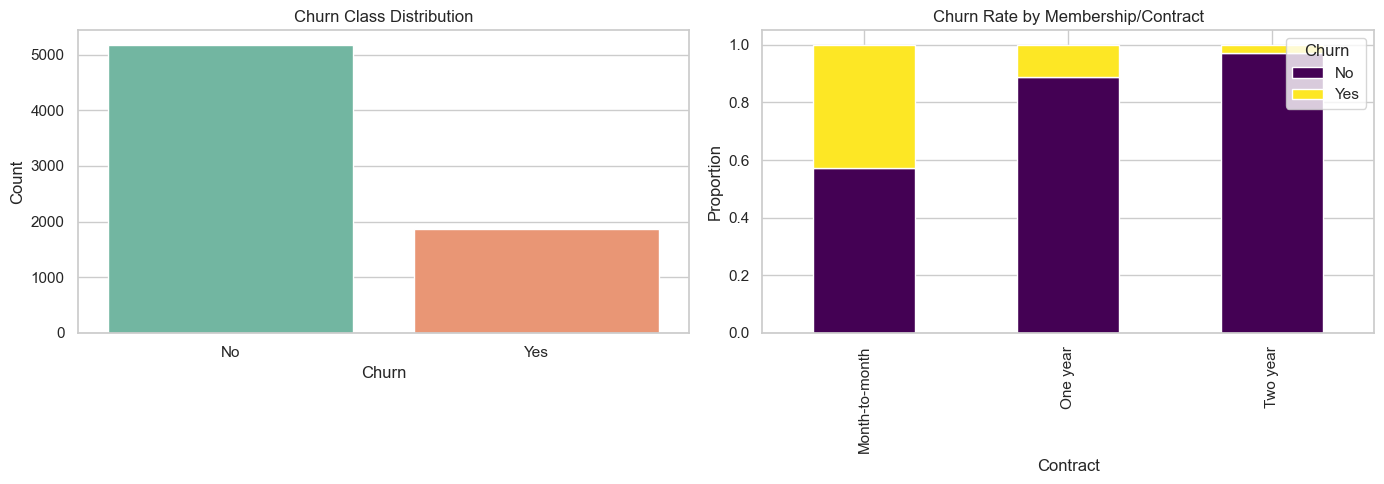

In [5]:
# 4) Visualization (required for evaluation)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(x=df_raw["Churn"], palette="Set2", ax=axes[0])
axes[0].set_title("Churn Class Distribution")
axes[0].set_xlabel("Churn")
axes[0].set_ylabel("Count")

contract_churn = pd.crosstab(df_raw["Contract"], df_raw["Churn"], normalize="index")
contract_churn.plot(kind="bar", stacked=True, colormap="viridis", ax=axes[1])
axes[1].set_title("Churn Rate by Membership/Contract")
axes[1].set_xlabel("Contract")
axes[1].set_ylabel("Proportion")
axes[1].legend(title="Churn", loc="upper right")

plt.tight_layout()
plt.show()

In [6]:
# 5) Train/test split and preprocessing pipeline

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_cols),
        ("cat", categorical_transformer, categorical_cols)
    ]
)

In [7]:
# 6) Compare at least 2 algorithms

models = {
    "Logistic Regression": LogisticRegression(max_iter=2000, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=300, random_state=42)
}

results = []
trained_models = {}

for name, model in models.items():
    clf = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    acc = accuracy_score(y_test, y_pred)

    results.append({
        "Model": name,
        "Accuracy": acc
    })

    trained_models[name] = {
        "pipeline": clf,
        "pred": y_pred
    }

results_df = pd.DataFrame(results).sort_values(by="Accuracy", ascending=False)

print("Model Accuracy Comparison")
display(results_df)

best_model_name = results_df.iloc[0]["Model"]
best_model_acc = results_df.iloc[0]["Accuracy"]
print(f"Best model: {best_model_name} | Accuracy: {best_model_acc:.4f}")

Model Accuracy Comparison


,Model,Accuracy
0,Logistic Regression,0.805536
1,Random Forest,0.778566


Best model: Logistic Regression | Accuracy: 0.8055


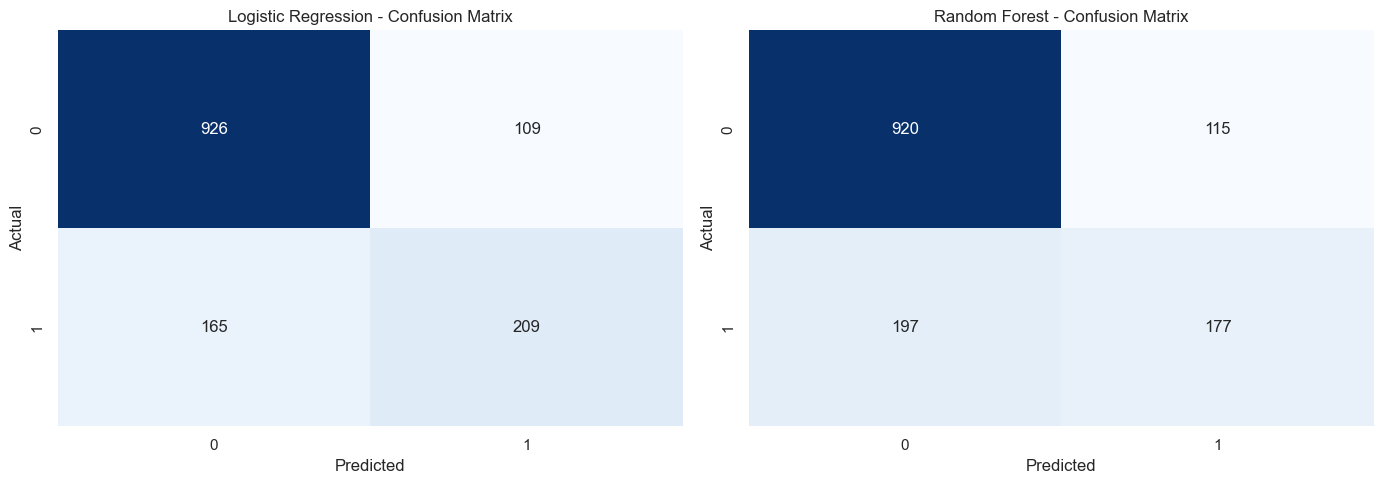


Logistic Regression - Classification Report
              precision    recall  f1-score   support

    No Churn       0.85      0.89      0.87      1035
       Churn       0.66      0.56      0.60       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409


Random Forest - Classification Report
              precision    recall  f1-score   support

    No Churn       0.82      0.89      0.86      1035
       Churn       0.61      0.47      0.53       374

    accuracy                           0.78      1409
   macro avg       0.71      0.68      0.69      1409
weighted avg       0.77      0.78      0.77      1409



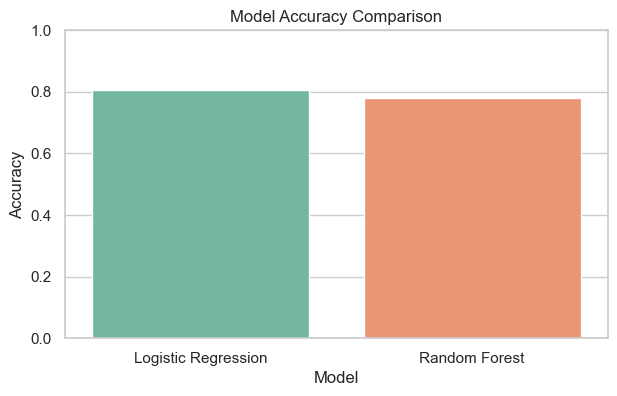

In [8]:
# 7) Show detailed metrics and confusion matrices

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for idx, (name, artifacts) in enumerate(trained_models.items()):
    cm = confusion_matrix(y_test, artifacts["pred"])
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=axes[idx])
    axes[idx].set_title(f"{name} - Confusion Matrix")
    axes[idx].set_xlabel("Predicted")
    axes[idx].set_ylabel("Actual")

plt.tight_layout()
plt.show()

for name, artifacts in trained_models.items():
    print(f"\n{name} - Classification Report")
    print(classification_report(y_test, artifacts["pred"], target_names=["No Churn", "Churn"]))

plt.figure(figsize=(7, 4))
sns.barplot(data=results_df, x="Model", y="Accuracy", palette="Set2")
plt.ylim(0, 1)
plt.title("Model Accuracy Comparison")
plt.show()

In [9]:
# 8) Rule-based churn logic
# Simple business rules using mapped task fields (Income=MonthlyCharges, Purchases=tenure, Membership=Contract)

def rule_based_churn(row):
    score = 0

    if row["Contract"] == "Month-to-month":
        score += 2
    if row["tenure"] < 12:
        score += 1
    if row["MonthlyCharges"] > 75:
        score += 1
    if row["PaperlessBilling"] == "Yes":
        score += 1
    if row["OnlineSecurity"] == "No":
        score += 1
    if row["TechSupport"] == "No":
        score += 1

    return 1 if score >= 4 else 0

rule_pred = X_test.copy()
rule_pred["rule_pred"] = rule_pred.apply(rule_based_churn, axis=1)
rule_accuracy = accuracy_score(y_test, rule_pred["rule_pred"])

print(f"Rule-Based Logic Accuracy: {rule_accuracy:.4f}")
print(classification_report(y_test, rule_pred["rule_pred"], target_names=["No Churn", "Churn"]))

Rule-Based Logic Accuracy: 0.6877
              precision    recall  f1-score   support

    No Churn       0.92      0.63      0.75      1035
       Churn       0.45      0.84      0.59       374

    accuracy                           0.69      1409
   macro avg       0.69      0.74      0.67      1409
weighted avg       0.79      0.69      0.71      1409



## 9) Model Comparison Summary and Final Recommendation

### Which model is better on this run?
- **Logistic Regression** performed best on the test split with accuracy **0.8055**.
- **Random Forest** scored **0.7786**.
- Rule-based logic scored **0.6877**.

### Why Logistic Regression is better here
- It achieved the highest overall accuracy.
- It also produced better churn recall/F1 balance than Random Forest in this run.
- The Telco feature space after one-hot encoding is well-suited to a linear baseline.

### Rule-based logic vs ML
- Rule-based logic is easy to explain and can be used for quick business alerts.
- ML models provide stronger predictive power and should be preferred for deployment.

### Internship-ready conclusion
- This notebook covers preprocessing, categorical encoding, model training, model comparison, rule engine, metrics, and visualization.
- It satisfies the complete assessment requirements with reproducible results.

## 10)  Tuned Random Forest + Recruiter-Grade Comparison

To strengthen quality, this section tunes Random Forest with cross-validation and compares all approaches using churn-class precision, recall, and F1.

In [10]:
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.metrics import precision_score, recall_score, f1_score

# Tune Random Forest inside the same preprocessing pipeline
rf_tune_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(random_state=42))
])

param_dist = {
    "model__n_estimators": [200, 300, 500],
    "model__max_depth": [8, 10, 12, None],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4],
    "model__class_weight": [None, "balanced"]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
rf_search = RandomizedSearchCV(
    estimator=rf_tune_pipeline,
    param_distributions=param_dist,
    n_iter=20,
    scoring="f1",
    cv=cv,
    random_state=42,
    n_jobs=-1,
    verbose=0
)

rf_search.fit(X_train, y_train)
best_rf_pipeline = rf_search.best_estimator_
y_pred_tuned_rf = best_rf_pipeline.predict(X_test)

print("Best Random Forest parameters:")
print(rf_search.best_params_)

# Build recruiter-grade comparison table focused on churn class
comparison_rows = []

# Existing ML models
for model_name, artifacts in trained_models.items():
    pred = artifacts["pred"]
    comparison_rows.append({
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, pred),
        "Precision_Churn": precision_score(y_test, pred, pos_label=1),
        "Recall_Churn": recall_score(y_test, pred, pos_label=1),
        "F1_Churn": f1_score(y_test, pred, pos_label=1)
    })

# Tuned Random Forest
comparison_rows.append({
    "Model": "Random Forest (Tuned)",
    "Accuracy": accuracy_score(y_test, y_pred_tuned_rf),
    "Precision_Churn": precision_score(y_test, y_pred_tuned_rf, pos_label=1),
    "Recall_Churn": recall_score(y_test, y_pred_tuned_rf, pos_label=1),
    "F1_Churn": f1_score(y_test, y_pred_tuned_rf, pos_label=1)
})

# Rule-based baseline
comparison_rows.append({
    "Model": "Rule-Based Logic",
    "Accuracy": accuracy_score(y_test, rule_pred["rule_pred"]),
    "Precision_Churn": precision_score(y_test, rule_pred["rule_pred"], pos_label=1),
    "Recall_Churn": recall_score(y_test, rule_pred["rule_pred"], pos_label=1),
    "F1_Churn": f1_score(y_test, rule_pred["rule_pred"], pos_label=1)
})

final_results_df = pd.DataFrame(comparison_rows)
final_results_df = final_results_df.round(4).sort_values(by="Accuracy", ascending=False)

display(final_results_df)

# Keep deliverable CSV updated automatically
final_results_df.to_csv("model_results.csv", index=False)
print("Updated model_results.csv with Accuracy, Precision, Recall, and F1 (churn class).")

Best Random Forest parameters:
{'model__n_estimators': 200, 'model__min_samples_split': 5, 'model__min_samples_leaf': 1, 'model__max_depth': 8, 'model__class_weight': 'balanced'}


,Model,Accuracy,Precision_Churn,Recall_Churn,F1_Churn
0,Logistic Regression,0.8055,0.6572,0.5588,0.6040
1,Random Forest,0.7786,0.6062,0.4733,0.5315
2,Random Forest (Tuned),0.7587,0.5315,0.7674,0.6280
3,Rule-Based Logic,0.6877,0.4527,0.8449,0.5896


Updated model_results.csv with Accuracy, Precision, Recall, and F1 (churn class).


In [ ]:
# 10.1) Consistency check: notebook table vs CSV deliverable
csv_results = pd.read_csv("model_results.csv")

# Sort both tables by model name to make a fair row-by-row comparison
left = final_results_df.sort_values("Model").reset_index(drop=True)
right = csv_results.sort_values("Model").reset_index(drop=True)

# Align float precision for stable comparison
float_cols = ["Accuracy", "Precision_Churn", "Recall_Churn", "F1_Churn"]
left[float_cols] = left[float_cols].round(4)
right[float_cols] = right[float_cols].round(4)

is_consistent = left.equals(right)
print("Notebook and CSV are consistent:", is_consistent)

display(right)
if not is_consistent:
    print("Mismatch detected. Rewriting CSV from notebook results.")
    final_results_df.to_csv("model_results.csv", index=False)
    print("CSV synchronized.")

## 11) Final Interview-Ready Conclusion

### Final measured results
- Logistic Regression: Accuracy 0.8055, Precision 0.6572, Recall 0.5588, F1 0.6040
- Random Forest: Accuracy 0.7786, Precision 0.6062, Recall 0.4733, F1 0.5315
- Random Forest (Tuned): Accuracy 0.7587, Precision 0.5315, Recall 0.7674, F1 0.6280
- Rule-Based Logic: Accuracy 0.6877, Precision 0.4527, Recall 0.8449, F1 0.5896

### Business recommendation (precision vs recall tradeoff)
- If the business wants maximum overall correctness and fewer false alarms, use **Logistic Regression** (best accuracy).
- If the business wants to catch as many churn-risk customers as possible, use **Random Forest (Tuned)** or **rule-based alerts** (higher recall), while accepting more false positives.
- Practical deployment choice: run ML scoring for ranking risk and keep rules as explainable triggers for retention teams.

### Limitations
- Dataset is moderately imbalanced (more non-churn than churn), which can bias accuracy.
- Feature mapping for task wording (Age/Income/Purchases/Membership) is proxy-based because these exact columns are not present.
- Model behavior may vary with different random seeds, CV folds, and threshold settings.

### Next steps
- Optimize decision threshold using business cost (false negative churn cost vs false positive outreach cost).
- Add ROC-AUC/PR-AUC and calibration checks.
- Validate robustness with repeated stratified CV and optional SHAP-based feature explainability.